# Laboratorio 5 — Clasificación de tweets sobre desastres reales
### Minería de texto y análisis de sentimiento — CC3084 Data Science

**Universidad del Valle de Guatemala — Facultad de Ingeniería**

Este notebook documenta el **avance** solicitado para el 27 de agosto de 2026, que cubre:

1. Descripción del conjunto de datos (`train.csv`, `test.csv`).
2. Limpieza y preprocesamiento de texto, con la explicación de cada paso.
3. Análisis de frecuencia de **unigramas** (incluye nube de palabras).
4. Análisis de frecuencia de **bigramas**.
5. Descripción y evaluación de un **modelo preliminar** de clasificación.

El dataset corresponde a la competencia de Kaggle *[Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started)*. El objetivo final del laboratorio es construir un clasificador que determine si un tweet (`text`) se refiere a un desastre real (`target = 1`) o no (`target = 0`).

> Los puntos 6 a 11 del enunciado (selección del mejor modelo, función de clasificación, análisis de sentimiento y variable de "negatividad") se completarán en el informe final (entrega del 30 de agosto de 2026).

## 0. Librerías y configuración

Se utilizan los siguientes módulos de Python (sugeridos en el enunciado del laboratorio):

- **pandas / numpy**: carga y manipulación de los datos.
- **matplotlib / seaborn**: visualizaciones (histogramas, barras, matrices de confusión).
- **nltk (Natural Language Toolkit)**: tokenización, *stopwords* en inglés y lematización.
- **wordcloud**: nube de palabras.
- **emoji**: detección de emoticones/emojis dentro de los tweets.
- **scikit-learn**: vectorización TF-IDF y modelos de clasificación (Naive Bayes, Regresión Logística) para el modelo preliminar.

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

import emoji
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42

In [2]:
# Descarga (una sola vez) de los recursos de NLTK necesarios para tokenizar,
# quitar stopwords y lematizar en inglés.
recursos_nltk = [
    ("stopwords", "corpora/stopwords"),
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab"),
    ("wordnet", "corpora/wordnet"),
    ("omw-1.4", "corpora/omw-1.4"),
]

for recurso, ruta in recursos_nltk:
    try:
        nltk.data.find(ruta)
    except LookupError:
        nltk.download(recurso, quiet=True)

## 1. Carga y descripción de los datos

**Descripción del dataset (según el enunciado):**

| Columna | Descripción |
|---|---|
| `id` | Identificador único del tweet |
| `keyword` | Palabra clave asociada al tweet (puede estar en blanco) |
| `location` | Ubicación de origen del tweet (texto libre, puede estar en blanco) |
| `text` | Texto del tweet |
| `target` | Etiqueta: `1` si el tweet se refiere a un desastre real, `0` si no (solo en `train.csv`) |

In [3]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

print(f"train.csv: {train.shape[0]} filas, {train.shape[1]} columnas")
print(f"test.csv:  {test.shape[0]} filas, {test.shape[1]} columnas")
train.head()

train.csv: 7613 filas, 5 columnas
test.csv:  3263 filas, 4 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
train.info()
print()
faltantes = train.isna().sum().to_frame("valores_faltantes")
faltantes["% faltante"] = (faltantes["valores_faltantes"] / len(train) * 100).round(2)
faltantes

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB



,valores_faltantes,% faltante
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Observación:** `keyword` solo tiene un porcentaje muy bajo de valores faltantes (aprox. 0.8%), mientras que `location` tiene una proporción alta de valores nulos (aprox. 33%). Esto ya sugiere que `location` será poco confiable como variable predictiva sin un trabajo importante de normalización, mientras que `keyword` sí es aprovechable.

In [5]:
print("Filas totalmente duplicadas:", train.duplicated().sum())
print("Textos duplicados (mismo `text`):", train["text"].duplicated().sum())

# Tweets con texto idéntico pero con etiquetas distintas: son ruido en el etiquetado
duplicados_texto = train[train["text"].duplicated(keep=False)]
inconsistentes = duplicados_texto.groupby("text")["target"].nunique()
inconsistentes = inconsistentes[inconsistentes > 1]
print(f"Textos duplicados con etiqueta inconsistente entre sí: {len(inconsistentes)}")
train[train["text"].isin(inconsistentes.index)].sort_values("text").head(10)

Filas totalmente duplicadas: 0
Textos duplicados (mismo `text`): 110
Textos duplicados con etiqueta inconsistente entre sí: 18


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into ...,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into ...,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into ...,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,0
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1


**Observación:** existen tweets con el mismo texto pero etiquetados de forma distinta (probablemente error humano al anotar el dataset original). Es poco frecuente, por lo que no se eliminan filas en esta etapa, pero se documenta como una fuente de ruido/techo de desempeño para cualquier modelo (ningún clasificador podrá superar el 100% de exactitud sobre estos casos).

### Distribución de la variable objetivo (`target`)

In [6]:
conteo_target = train["target"].value_counts().sort_index()
proporcion_target = train["target"].value_counts(normalize=True).sort_index() * 100

resumen_target = pd.DataFrame({"conteo": conteo_target, "% del total": proporcion_target.round(2)})
resumen_target.index = ["0 - No desastre", "1 - Desastre real"]
resumen_target

,conteo,% del total
0 - No desastre,4342,57.03
1 - Desastre real,3271,42.97


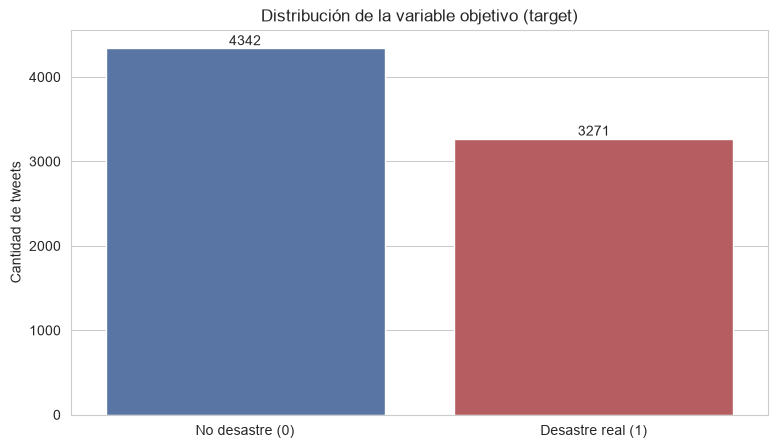

In [7]:
fig, ax = plt.subplots()
sns.countplot(data=train, x="target", hue="target", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No desastre (0)", "Desastre real (1)"])
ax.set_title("Distribución de la variable objetivo (target)")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de tweets")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Observación:** hay un desbalance moderado (aprox. 57% / 43%), no severo. No se aplica sobremuestreo/submuestreo, pero sí se tendrá cuidado de no evaluar los modelos solo con *accuracy*, sino también con *precision*, *recall* y *F1*.

### Análisis de la columna `keyword`

In [8]:
print(f"Número de keywords distintas: {train['keyword'].nunique()}")
train["keyword"].value_counts().head(15)

Número de keywords distintas: 221


keyword
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
fear           40
outbreak       40
siren          40
twister        40
windstorm      40
collision      39
Name: count, dtype: int64

In [9]:
keyword_target = (
    train.dropna(subset=["keyword"])
    .groupby("keyword")["target"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "proporcion_desastre", "count": "n_tweets"})
)
keyword_target = keyword_target[keyword_target["n_tweets"] >= 10]

print("Keywords más asociadas a DESASTRE REAL:")
display(keyword_target.sort_values("proporcion_desastre", ascending=False).head(10))

print("\nKeywords más asociadas a NO DESASTRE:")
display(keyword_target.sort_values("proporcion_desastre").head(10))

Keywords más asociadas a DESASTRE REAL:


,proporcion_desastre,n_tweets
keyword,,
wreckage,1.000000,39
debris,1.000000,37
derailment,1.000000,39
outbreak,0.975000,40
oil%20spill,0.973684,38
typhoon,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29



Keywords más asociadas a NO DESASTRE:


,proporcion_desastre,n_tweets
keyword,,
aftershock,0.000000,34
body%20bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body%20bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


**Observación:** `keyword` es una señal bastante fuerte por sí sola: hay palabras clave que casi siempre corresponden a desastre real (p. ej. términos relacionados a descarrilamientos, escombros o derrumbes) y otras que casi nunca lo son (p. ej. palabras con doble sentido/uso coloquial). Esta columna es candidata a usarse como *feature* adicional en el modelo final.

### Análisis de la columna `location`

In [10]:
print(f"Número de ubicaciones distintas (texto libre, sin normalizar): {train['location'].nunique()}")
train["location"].value_counts().head(15)

Número de ubicaciones distintas (texto libre, sin normalizar): 3341


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Australia           18
Chicago, IL         18
Name: count, dtype: int64

**Observación:** `location` es texto libre ingresado por cada usuario: hay ubicaciones reales ("USA", "New York"), genéricas ("Worldwide", "Everywhere") y evidentemente inventadas o con emojis. Tiene alta cardinalidad y mucho ruido, por lo que **no se usará** en el modelo preliminar; normalizarla adecuadamente (mapear a país/continente) queda como posible mejora para el informe final.

### Longitud de los tweets

In [11]:
train["n_caracteres"] = train["text"].str.len()
train["n_palabras"] = train["text"].str.split().str.len()

train.groupby("target")[["n_caracteres", "n_palabras"]].describe().T

target                        0            1
n_caracteres count  4342.000000  3271.000000
             mean     95.706817   108.113421
             std      35.885924    29.309854
             min       7.000000    14.000000
             25%      68.000000    88.000000
             50%     101.000000   115.000000
             75%     130.000000   136.000000
             max     157.000000   151.000000
n_palabras   count  4342.000000  3271.000000
             mean     14.704744    15.167533
             std       6.161564     5.096806
             min       1.000000     2.000000
             25%      10.000000    11.000000
             50%      15.000000    15.000000
             75%      19.000000    19.000000
             max      31.000000    30.000000

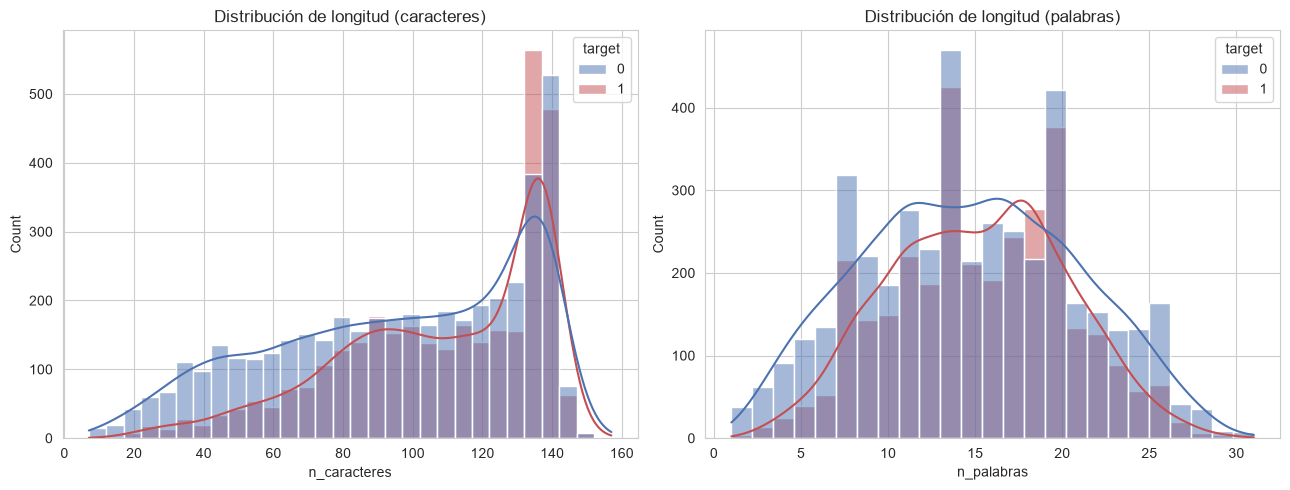

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=train, x="n_caracteres", hue="target", bins=30, kde=True, ax=axes[0],
             palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Distribución de longitud (caracteres)")

sns.histplot(data=train, x="n_palabras", hue="target", bins=25, kde=True, ax=axes[1],
             palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Distribución de longitud (palabras)")

plt.tight_layout()
plt.show()

**Observación:** los tweets de desastre real tienden a ser ligeramente más largos (en caracteres y en palabras) que los que no lo son. Esto es consistente con un estilo más informativo/tipo noticia (que suele incluir un enlace y más detalle) frente a un estilo conversacional/coloquial en los tweets que no son desastre.

### Presencia de URLs, menciones y hashtags (antes de limpiar)

In [13]:
def contiene_url(texto):
    return bool(re.search(r"https?://\S+|www\.\S+", texto))

def contiene_mencion(texto):
    return bool(re.search(r"@\w+", texto))

def contiene_hashtag(texto):
    return bool(re.search(r"#\w+", texto))

resumen_elementos = pd.DataFrame({
    "tiene_url": train["text"].apply(contiene_url),
    "tiene_mencion": train["text"].apply(contiene_mencion),
    "tiene_hashtag": train["text"].apply(contiene_hashtag),
    "target": train["target"],
})

(resumen_elementos.groupby("target")[["tiene_url", "tiene_mencion", "tiene_hashtag"]].mean() * 100).round(2)

,tiene_url,tiene_mencion,tiene_hashtag
target,,,
0,41.43,30.93,20.38
1,66.40,20.36,26.23


**Observación:** los tweets de desastre real contienen URLs con mayor frecuencia (probablemente enlaces a noticias), mientras que los tweets que no son desastre contienen más menciones (`@usuario`), consistente con un uso más conversacional. Esto refuerza la decisión de **eliminar** estos elementos del texto limpio (no aportan información léxica), aunque su sola *presencia* sí podría usarse como *feature* adicional más adelante.

## 2. Limpieza y preprocesamiento de texto

Se construye una función `limpiar_tweet()` que aplica, en orden, las siguientes transformaciones (siguiendo la sección 3.1 del enunciado). Cada decisión se explica y se justifica con base en el análisis exploratorio anterior:

1. **Minúsculas**: se convierte todo el texto a minúsculas para que "Fire" y "fire" se traten como el mismo token.
2. **Eliminar URLs**: se detectan con una expresión regular (`https?://...` o `www...`) y se eliminan; ya vimos que aparecen más en tweets de desastre real, pero el contenido de la URL en sí no aporta información léxica.
3. **Eliminar menciones (`@usuario`)**: los nombres de usuario son ruido para la clasificación (identifican personas, no el contenido del mensaje).
4. **Hashtags (`#palabra`)**: en vez de eliminar por completo la palabra, solo se quita el símbolo `#` y se conserva la palabra, ya que suele llevar información relevante (p. ej. `#wildfire` → `wildfire`).
5. **Caso especial "911"**: antes de eliminar los números, se revisa si vale la pena conservar el "911". Se protege temporalmente como el token `emergencianum` (ver análisis abajo) y luego sí se eliminan el resto de los números y signos de puntuación.
6. **Emojis/emoticones**: se detectan con el módulo `emoji` (ver análisis abajo) y se eliminan del texto limpio, aunque se guardan aparte por si se usan en el análisis de sentimiento del informe final.
7. **Signos de puntuación y caracteres no alfabéticos**: se eliminan con una expresión regular que solo conserva letras y espacios.
8. **Tokenización**: se separa el texto en palabras (*tokens*) usando `nltk.word_tokenize`.
9. **Stopwords**: se eliminan artículos, preposiciones y conjunciones en inglés (`nltk.corpus.stopwords`), **conservando las negaciones** (`no`, `not`, `nor`) porque son relevantes para un futuro análisis de sentimiento.
10. **Lematización**: se normalizan las variantes morfológicas de una palabra a su forma base (p. ej. "fires", "fired" → "fire") usando `WordNetLemmatizer`, para reducir la dispersión del vocabulario.

### Detección de emojis/emoticones

In [14]:
def extraer_emojis(texto):
    return [c for c in texto if c in emoji.EMOJI_DATA]

train["emojis"] = train["text"].apply(extraer_emojis)
train["n_emojis"] = train["emojis"].apply(len)

print(f"Tweets con al menos un emoji: {(train['n_emojis'] > 0).sum()} de {len(train)} "
      f"({(train['n_emojis'] > 0).mean() * 100:.2f}%)")
train.loc[train["n_emojis"] > 0, ["text", "emojis", "target"]].head(5)

Tweets con al menos un emoji: 10 de 7613 (0.13%)


,text,emojis,target
2171,How Missing JetÛªs Debris Could Have Floated ...,[©],1
2172,RÌ©union Debris Is Almost Surely From Flight 3...,[©],1
2173,RÌ©union Debris Is Almost Surely From Flight 3...,[©],1
2179,#love #food #fun Malaysian Prime Minister Naji...,[©],1
3479,Exploring New Worlds: Three Moments of an Expl...,[©],1


**Decisión:** los emojis son muy poco frecuentes en este dataset (tweets de 2013-2017 relacionados con desastres, de estilo más bien informativo/periodístico). Por eso se eliminan del texto que se usa para frecuencias de palabras y para el modelo preliminar, pero se guarda la columna `emojis` por separado para poder aprovecharla en el análisis de sentimiento del informe final.

### ¿Vale la pena quitar el "911"?

In [15]:
contiene_911 = train["text"].str.contains(r"\b911\b", regex=True)
print(f"Tweets que mencionan '911': {contiene_911.sum()}")
print("Proporción de target entre esos tweets:")
train.loc[contiene_911, "target"].value_counts(normalize=True).round(3)

Tweets que mencionan '911': 4
Proporción de target entre esos tweets:


target
1    0.75
0    0.25
Name: proportion, dtype: float64

**Decisión:** el número "911" (número de emergencia en EE. UU.) aparece en varios tweets y en una proporción alta de ellos corresponde efectivamente a un desastre real. Por eso **no se elimina como un número genérico**: se reemplaza por el token especial `emergencianum` antes de quitar el resto de los dígitos, para no perder esta señal útil.

### Función de limpieza completa

In [16]:
lematizador = WordNetLemmatizer()
stopwords_ingles = set(stopwords.words("english"))
# Se conservan las negaciones porque son relevantes para el análisis de sentimiento
stopwords_ingles -= {"no", "not", "nor"}

PATRON_URL = re.compile(r"https?://\S+|www\.\S+")
PATRON_MENCION = re.compile(r"@\w+")
PATRON_HASHTAG = re.compile(r"#(\w+)")
PATRON_911 = re.compile(r"\b911\b")
PATRON_NO_ALFA = re.compile(r"[^a-z\s]")


def limpiar_tweet(texto, quitar_stopwords=True, lematizar=True):
    '''Aplica el pipeline de limpieza descrito arriba y devuelve la lista de tokens.'''
    texto = texto.lower()
    texto = PATRON_URL.sub(" ", texto)
    texto = PATRON_MENCION.sub(" ", texto)
    texto = PATRON_HASHTAG.sub(r"\1", texto)
    texto = PATRON_911.sub(" emergencianum ", texto)
    texto = PATRON_NO_ALFA.sub(" ", texto)

    tokens = word_tokenize(texto)

    if quitar_stopwords:
        tokens = [t for t in tokens if t not in stopwords_ingles]

    tokens = [t for t in tokens if len(t) > 1]

    if lematizar:
        tokens = [lematizador.lemmatize(t) for t in tokens]

    return tokens


train["tokens"] = train["text"].apply(limpiar_tweet)
train["text_limpio"] = train["tokens"].apply(lambda tks: " ".join(tks))

train[["text", "text_limpio"]].head(10)

,text,text_limpio
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain cause flash flooding...
7,I'm on top of the hill and I can see a fire in...,top hill see fire wood
8,There's an emergency evacuation happening now ...,emergency evacuation happening building across...
9,I'm afraid that the tornado is coming to our a...,afraid tornado coming area


In [17]:
# Ejemplos "antes / después" que muestran distintos casos (URL, mención, hashtag, 911)
indice_911 = contiene_911[contiene_911].index[0]
ejemplos_idx = [0, 4, 5, indice_911]

for i in ejemplos_idx:
    print("ORIGINAL:", train.loc[i, "text"])
    print("LIMPIO  :", train.loc[i, "text_limpio"])
    print("-" * 80)

ORIGINAL: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
LIMPIO  : deed reason earthquake may allah forgive u
--------------------------------------------------------------------------------
ORIGINAL: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
LIMPIO  : got sent photo ruby alaska smoke wildfire pours school
--------------------------------------------------------------------------------
ORIGINAL: #RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires
LIMPIO  : rockyfire update california hwy closed direction due lake county fire cafire wildfire
--------------------------------------------------------------------------------
ORIGINAL: @_jeesss_ @Ethereal_7 Hello 911 yeah we have someone drowning here send a medic http://t.co/7GiglwdMhy
LIMPIO  : hello emergencianum yeah someone drowning send medic
-------------------------------------------------------------------

In [18]:
# Se aplica el mismo preprocesamiento a test.csv para dejarlo listo de cara al modelo
test["tokens"] = test["text"].apply(limpiar_tweet)
test["text_limpio"] = test["tokens"].apply(lambda tks: " ".join(tks))
test[["text", "text_limpio"]].head()

,text,text_limpio
0,Just happened a terrible car crash,happened terrible car crash
1,"Heard about #earthquake is different cities, s...",heard earthquake different city stay safe ever...
2,"there is a forest fire at spot pond, geese are...",forest fire spot pond goose fleeing across str...
3,Apocalypse lighting. #Spokane #wildfires,apocalypse lighting spokane wildfire
4,Typhoon Soudelor kills 28 in China and Taiwan,typhoon soudelor kill china taiwan


In [19]:
vacios = (train["text_limpio"].str.len() == 0).sum()
print(f"Tweets que quedaron vacíos tras la limpieza: {vacios}")
train.loc[train["text_limpio"].str.len() == 0, ["text", "target"]].head()

Tweets que quedaron vacíos tras la limpieza: 2


,text,target
4497,@Hurricane_Dame ???????? I don't have them the...,1
6766,@Ayshun_Tornado then don't,0


**Observación:** un pequeño número de tweets queda vacío tras la limpieza (eran solo una URL, una mención o puros signos de puntuación). Se conservan en el dataset —el vectorizador simplemente les asignará un vector de ceros—, pero se documenta este efecto secundario del preprocesamiento.

## 3. Análisis de unigramas (frecuencia de palabras)

Se calcula la frecuencia de cada palabra (unigrama) **por separado** para los tweets de desastre real (`target = 1`) y para los que no lo son (`target = 0`), usando los tokens ya limpios de la sección anterior. Esto responde directamente al punto 4 del enunciado.

In [20]:
tokens_desastre = [t for tokens in train.loc[train["target"] == 1, "tokens"] for t in tokens]
tokens_no_desastre = [t for tokens in train.loc[train["target"] == 0, "tokens"] for t in tokens]

frecuencia_desastre = Counter(tokens_desastre)
frecuencia_no_desastre = Counter(tokens_no_desastre)

print(f"Tokens totales en tweets de desastre real: {len(tokens_desastre)} ({len(frecuencia_desastre)} únicos)")
print(f"Tokens totales en tweets que NO son desastre: {len(tokens_no_desastre)} ({len(frecuencia_no_desastre)} únicos)")

Tokens totales en tweets de desastre real: 30535 (7048 únicos)
Tokens totales en tweets que NO son desastre: 35988 (9193 únicos)


In [21]:
top_desastre = pd.DataFrame(frecuencia_desastre.most_common(20), columns=["palabra", "frecuencia"])
top_no_desastre = pd.DataFrame(frecuencia_no_desastre.most_common(20), columns=["palabra", "frecuencia"])

pd.concat([top_desastre, top_no_desastre], axis=1, keys=["Desastre real (1)", "No desastre (0)"])

Desastre real (1)            No desastre (0)           
             palabra frecuencia         palabra frecuencia
0               fire        267            like        256
1               news        146             not        211
2                amp        135             amp        209
3           disaster        122             get        185
4                via        121             new        171
5                 no        115              no        151
6         california        115             one        139
7               year        112            body        119
8            suicide        112            time        106
9             police        109             day        104
10            people        106           video        102
11              home        105           would        101
12            family        105             via         99
13             train        100            love         96
14               not         99          people         94
15          building         95              go         93
16            killed         95             got         93
17             storm         95            know         91
18              like         94            fire         88
19         hiroshima         94             let         87

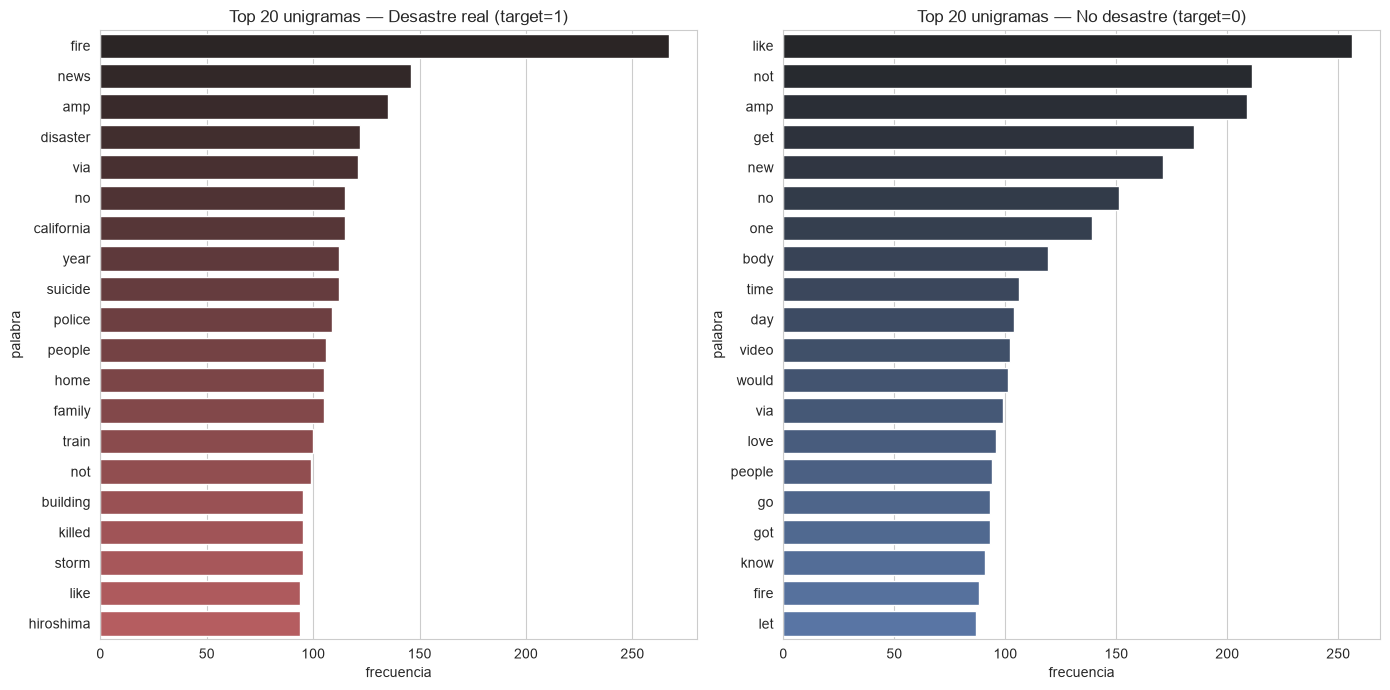

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(data=top_desastre, y="palabra", x="frecuencia", hue="palabra", ax=axes[0],
            color="#C44E52", legend=False)
axes[0].set_title("Top 20 unigramas — Desastre real (target=1)")

sns.barplot(data=top_no_desastre, y="palabra", x="frecuencia", hue="palabra", ax=axes[1],
            color="#4C72B0", legend=False)
axes[1].set_title("Top 20 unigramas — No desastre (target=0)")

plt.tight_layout()
plt.show()

### Nube de palabras

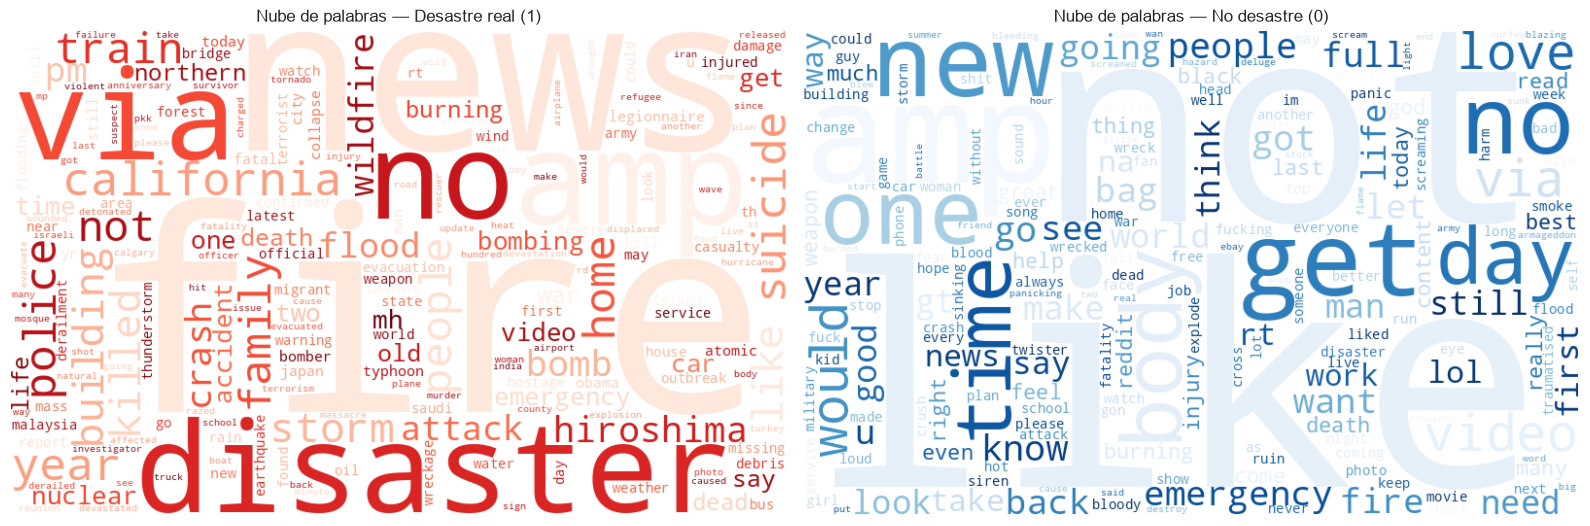

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_desastre = WordCloud(width=800, height=500, background_color="white",
                         colormap="Reds", random_state=RANDOM_STATE).generate_from_frequencies(frecuencia_desastre)
wc_no_desastre = WordCloud(width=800, height=500, background_color="white",
                            colormap="Blues", random_state=RANDOM_STATE).generate_from_frequencies(frecuencia_no_desastre)

axes[0].imshow(wc_desastre, interpolation="bilinear")
axes[0].set_title("Nube de palabras — Desastre real (1)")
axes[0].axis("off")

axes[1].imshow(wc_no_desastre, interpolation="bilinear")
axes[1].set_title("Nube de palabras — No desastre (0)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Palabras presentes en ambas categorías

In [24]:
vocab_desastre = set(frecuencia_desastre)
vocab_no_desastre = set(frecuencia_no_desastre)
vocab_comun = vocab_desastre & vocab_no_desastre

print(f"Vocabulario tweets desastre: {len(vocab_desastre)} palabras únicas")
print(f"Vocabulario tweets no desastre: {len(vocab_no_desastre)} palabras únicas")
print(f"Palabras en común entre ambas categorías: {len(vocab_comun)} "
      f"({len(vocab_comun) / len(vocab_desastre | vocab_no_desastre) * 100:.1f}% del vocabulario total)")

total_desastre = sum(frecuencia_desastre.values())
total_no_desastre = sum(frecuencia_no_desastre.values())

comparacion = pd.DataFrame({"palabra": list(vocab_comun)})
comparacion["frec_desastre"] = comparacion["palabra"].map(frecuencia_desastre)
comparacion["frec_no_desastre"] = comparacion["palabra"].map(frecuencia_no_desastre)
comparacion["prob_desastre"] = comparacion["frec_desastre"] / total_desastre
comparacion["prob_no_desastre"] = comparacion["frec_no_desastre"] / total_no_desastre
comparacion["log_ratio"] = np.log((comparacion["prob_desastre"] + 1e-6) /
                                   (comparacion["prob_no_desastre"] + 1e-6))
comparacion = comparacion[(comparacion["frec_desastre"] + comparacion["frec_no_desastre"]) >= 15]

print("\nPalabras comunes MÁS asociadas a desastre real (log-ratio alto):")
display(comparacion.sort_values("log_ratio", ascending=False).head(10))

print("\nPalabras comunes MÁS asociadas a NO desastre (log-ratio bajo):")
display(comparacion.sort_values("log_ratio").head(10))

print("\nPalabras 'neutrales' (proporción similar en ambas categorías):")
display(comparacion.reindex(comparacion["log_ratio"].abs().sort_values().index).head(10))

Vocabulario tweets desastre: 7048 palabras únicas
Vocabulario tweets no desastre: 9193 palabras únicas
Palabras en común entre ambas categorías: 3575 (28.2% del vocabulario total)

Palabras comunes MÁS asociadas a desastre real (log-ratio alto):


,palabra,frec_desastre,frec_no_desastre,prob_desastre,prob_no_desastre,log_ratio
2761,hiroshima,94,1,0.003078,0.000028,4.672576
3066,mh,73,1,0.002391,0.000028,4.419834
467,bomber,61,1,0.001998,0.000028,4.240331
407,typhoon,58,1,0.001899,0.000028,4.189926
941,malaysia,49,1,0.001605,0.000028,4.021400
3338,spill,43,1,0.001408,0.000028,3.890866
1675,outbreak,41,1,0.001343,0.000028,3.843273
554,wildfire,80,2,0.002620,0.000056,3.835739
2542,saudi,40,1,0.001310,0.000028,3.818599
2309,wreckage,40,1,0.001310,0.000028,3.818599



Palabras comunes MÁS asociadas a NO desastre (log-ratio bajo):


,palabra,frec_desastre,frec_no_desastre,prob_desastre,prob_no_desastre,log_ratio
3462,bag,2,83,0.000065,0.002306,-3.546663
1167,ruin,1,39,0.000033,0.001084,-3.470094
2371,ebay,1,29,0.000033,0.000806,-3.174146
1043,electrocute,1,28,0.000033,0.000778,-3.139099
3062,handbag,1,24,0.000033,0.000667,-2.985162
310,cake,1,22,0.000033,0.000611,-2.898287
2356,leather,1,21,0.000033,0.000584,-2.851845
3224,aftershock,1,19,0.000033,0.000528,-2.751941
424,mayhem,1,19,0.000033,0.000528,-2.751941
2785,womens,1,17,0.000033,0.000472,-2.640938



Palabras 'neutrales' (proporción similar en ambas categorías):


,palabra,frec_desastre,frec_no_desastre,prob_desastre,prob_no_desastre,log_ratio
2884,first,50,59,0.001637,0.001639,-0.001202
437,another,33,39,0.001081,0.001084,-0.002740
2847,could,38,45,0.001244,0.001250,-0.004761
3229,plan,35,41,0.001146,0.001139,0.006083
1119,weapon,41,48,0.001343,0.001334,0.006678
884,school,32,38,0.001048,0.001056,-0.007531
3340,said,26,31,0.000851,0.000861,-0.011565
853,problem,10,12,0.000327,0.000333,-0.017955
2898,responder,15,18,0.000491,0.000500,-0.017973
2968,leave,13,15,0.000426,0.000417,0.021161


**Discusión (unigramas):**

- Una parte importante del vocabulario (ver porcentaje calculado arriba) aparece en **ambas** categorías: palabras muy comunes en inglés (`like`, `im`, `new`, `people`, `via`) siguen presentes incluso tras quitar *stopwords*, porque son de uso general y no exclusivas del lenguaje de desastres.
- Sin embargo, dentro de ese vocabulario compartido hay diferencias claras de *proporción*: palabras como las que encabezan la lista de "log-ratio alto" aparecen casi siempre en el contexto de un desastre real, mientras que las de "log-ratio bajo" son casi exclusivas del uso coloquial/figurado (p. ej. "estoy que ardo" en sentido de estar enojado o emocionado, no de un incendio real).
- **Palabras que probablemente ayuden al modelo:** los unigramas que son casi exclusivos de una sola categoría (extremos del log-ratio) y las *keywords* más determinantes vistas en la sección 1 (p. ej. términos ligados a desastres estructurales/naturales severos).
- **Palabras que probablemente NO ayuden (o incluso confundan):** los términos ambiguos/polisémicos que aparecen en ambas categorías con proporciones parecidas (lista de "palabras neutrales"), ya que su sola presencia no permite distinguir el contexto — de ahí la utilidad de mirar **bigramas** en la siguiente sección.

## 4. Análisis de bigramas

Un unigrama por sí solo pierde el **contexto**: por ejemplo, la palabra "bomber" puede aparecer tanto en "suicide bomber" (desastre real) como en frases coloquiales. Los bigramas (pares de palabras consecutivas) permiten capturar frases más específicas y, por lo tanto, más informativas para la clasificación.

Se generan los bigramas con `nltk.util.ngrams` sobre los tokens ya limpios (sin *stopwords*, lematizados), por separado para cada clase, y se calcula tanto su **frecuencia** como su **probabilidad condicional** P(palabra2 | palabra1) = frecuencia(palabra1, palabra2) / frecuencia(palabra1).

In [25]:
def generar_bigramas(lista_de_tokens):
    bigramas = []
    for tokens in lista_de_tokens:
        bigramas.extend(ngrams(tokens, 2))
    return bigramas


bigramas_desastre = generar_bigramas(train.loc[train["target"] == 1, "tokens"])
bigramas_no_desastre = generar_bigramas(train.loc[train["target"] == 0, "tokens"])

frecuencia_bigramas_desastre = Counter(bigramas_desastre)
frecuencia_bigramas_no_desastre = Counter(bigramas_no_desastre)

print(f"Bigramas totales en desastre real: {len(bigramas_desastre)} "
      f"({len(frecuencia_bigramas_desastre)} únicos)")
print(f"Bigramas totales en no desastre: {len(bigramas_no_desastre)} "
      f"({len(frecuencia_bigramas_no_desastre)} únicos)")

Bigramas totales en desastre real: 27265 (18852 únicos)
Bigramas totales en no desastre: 31647 (26359 únicos)


In [26]:
top_bigramas_desastre = pd.DataFrame(
    [(f"{w1} {w2}", c) for (w1, w2), c in frecuencia_bigramas_desastre.most_common(15)],
    columns=["bigrama", "frecuencia"],
)
top_bigramas_no_desastre = pd.DataFrame(
    [(f"{w1} {w2}", c) for (w1, w2), c in frecuencia_bigramas_no_desastre.most_common(15)],
    columns=["bigrama", "frecuencia"],
)

pd.concat([top_bigramas_desastre, top_bigramas_no_desastre], axis=1,
          keys=["Desastre real (1)", "No desastre (0)"])

Desastre real (1)                  No desastre (0)           
                bigrama frecuencia               bigrama frecuencia
0        suicide bomber         60              body bag         49
1   northern california         41            cross body         39
2             oil spill         38           liked video         34
3   california wildfire         36             look like         32
4      burning building         36                gon na         32
5       suicide bombing         35                 gt gt         30
6      bomber detonated         30                wan na         30
7          confirmed mh         29             full read         28
8              year old         29             feel like         25
9                yr old         29          body bagging         24
10           home razed         29      burning building         23
11  severe thunderstorm         28     reddit quarantine         21
12          mass murder         28  quarantine offensive         21
13          latest home         28     offensive content         20
14       razed northern         28        content policy         20

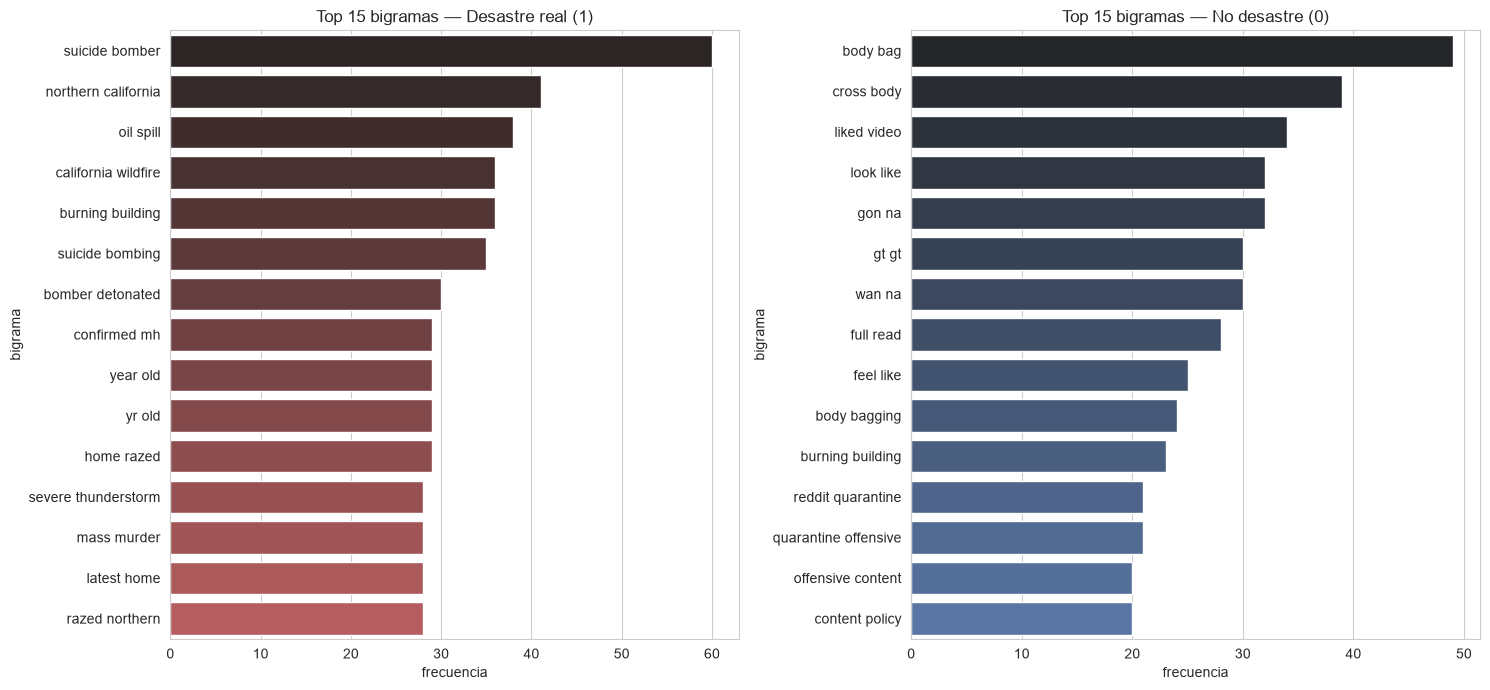

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(data=top_bigramas_desastre, y="bigrama", x="frecuencia", hue="bigrama", ax=axes[0],
            color="#C44E52", legend=False)
axes[0].set_title("Top 15 bigramas — Desastre real (1)")

sns.barplot(data=top_bigramas_no_desastre, y="bigrama", x="frecuencia", hue="bigrama", ax=axes[1],
            color="#4C72B0", legend=False)
axes[1].set_title("Top 15 bigramas — No desastre (0)")

plt.tight_layout()
plt.show()

### Probabilidad condicional de bigramas

In [28]:
def probabilidad_condicional(bigramas_contador, unigramas_contador, palabra1, top_n=8):
    '''Devuelve, para una palabra1 dada, sus bigramas más frecuentes junto con
    P(palabra2 | palabra1) = frecuencia(palabra1, palabra2) / frecuencia(palabra1).'''
    candidatos = {w2: c for (w1, w2), c in bigramas_contador.items() if w1 == palabra1}
    total = unigramas_contador[palabra1]
    filas = [(f"{palabra1} {w2}", c, c / total) for w2, c in candidatos.items()]
    df = pd.DataFrame(filas, columns=["bigrama", "frecuencia", "P(palabra2 | palabra1)"])
    return df.sort_values("frecuencia", ascending=False).head(top_n)


palabra_frecuente_desastre = top_desastre.iloc[0]["palabra"]
palabra_frecuente_no_desastre = top_no_desastre.iloc[0]["palabra"]

print(f"P(palabra2 | '{palabra_frecuente_desastre}') en tweets de desastre real:")
display(probabilidad_condicional(frecuencia_bigramas_desastre, frecuencia_desastre, palabra_frecuente_desastre))

print(f"\nP(palabra2 | '{palabra_frecuente_no_desastre}') en tweets que NO son desastre:")
display(probabilidad_condicional(frecuencia_bigramas_no_desastre, frecuencia_no_desastre,
                                  palabra_frecuente_no_desastre))

P(palabra2 | 'fire') en tweets de desastre real:


,bigrama,frecuencia,P(palabra2 | palabra1)
17,fire truck,10,0.037453
63,fire alarm,7,0.026217
5,fire caught,7,0.026217
98,fire killed,5,0.018727
0,fire near,4,0.014981
10,fire burning,4,0.014981
38,fire california,4,0.014981
76,fire fire,4,0.014981



P(palabra2 | 'like') en tweets que NO son desastre:


,bigrama,frecuencia,P(palabra2 | palabra1)
156,like sinking,6,0.023438
125,like mudslide,6,0.023438
185,like war,4,0.015625
180,like tsunami,4,0.015625
42,like jeb,4,0.015625
12,like year,3,0.011719
36,like burning,2,0.007812
27,like bitch,2,0.007812


**Discusión — ¿vale la pena explorar bigramas (o trigramas) para analizar el contexto?**

Sí. Los resultados anteriores muestran varios bigramas que son mucho más específicos y menos ambiguos que sus unigramas por separado (por ejemplo, combinaciones de una palabra genérica con una segunda palabra que sí fija el contexto de desastre real, como se observa en el top de bigramas de la clase 1 frente a la clase 0). Esto es evidencia de que:

1. **El contexto local de 2 palabras reduce la ambigüedad** de términos que por sí solos podrían tener uso figurado o coloquial.
2. **La probabilidad condicional** P(palabra2 | palabra1) muestra que, dada la misma palabra inicial, las continuaciones más probables difieren claramente entre ambas categorías — es información que un modelo de solo unigramas no puede aprovechar directamente.
3. El costo es un **vocabulario mucho más disperso** (hay muchos más bigramas únicos que unigramas, y la mayoría aparece solo 1 o 2 veces), por lo que en la práctica conviene combinar unigramas + bigramas (no reemplazar unos por otros) y filtrar los n-gramas demasiado raros. Explorar trigramas es posible, pero con ~7,600 tweets el vocabulario de trigramas sería aún más disperso y con pocas repeticiones útiles, por lo que se prioriza unigramas + bigramas para el modelo preliminar.

## 5. Modelo preliminar de clasificación

**Enfoque:** se representa cada tweet limpio como un vector **TF-IDF** (*Term Frequency – Inverse Document Frequency*) construido con **unigramas y bigramas** (`ngram_range=(1, 2)`), ya que la sección anterior mostró que los bigramas aportan contexto que los unigramas solos no capturan. Se filtran los n-gramas demasiado raros (`min_df=3`) para reducir ruido y dimensionalidad, y se limita el vocabulario a los 10,000 n-gramas de mayor peso (`max_features`).

**Cómo se aborda el contexto:** en vez de tratar el texto como una simple bolsa de palabras individuales, incluir bigramas en el vectorizador permite que el modelo "vea" combinaciones de dos palabras consecutivas (p. ej. una palabra genérica seguida de otra que fija su sentido literal de desastre), capturando así parte del contexto sin necesitar un modelo de lenguaje más complejo.

**Algoritmos utilizados (modelos preliminares, se ampliará en el informe final):**

- **Naive Bayes Multinomial**: modelo probabilístico clásico y muy usado como *baseline* para clasificación de texto; rápido de entrenar y funciona bien con vectores dispersos de conteos/TF-IDF.
- **Regresión Logística**: modelo lineal que suele funcionar muy bien con espacios de alta dimensionalidad y dispersos como TF-IDF, y que además permite interpretar qué n-gramas más "empujan" la predicción hacia cada clase (coeficientes).

**Partición de datos:** 80% entrenamiento / 20% prueba, de forma estratificada por `target` para conservar la proporción de clases en ambos subconjuntos.

**Métricas:** *accuracy*, *precision*, *recall* y *F1-score* (dado el desbalance moderado observado en la sección 1, F1 es más informativa que la exactitud por sí sola).

In [29]:
X = train["text_limpio"]
y = train["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} tweets")
print(f"Prueba:        {X_test.shape[0]} tweets")
print(f"Proporción de clase positiva - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Entrenamiento: 6090 tweets
Prueba:        1523 tweets
Proporción de clase positiva - train: 0.430 | test: 0.429


In [30]:
vectorizador_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=10000,
)

X_train_tfidf = vectorizador_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizador_tfidf.transform(X_test)

print(f"Dimensión de la matriz TF-IDF (entrenamiento): {X_train_tfidf.shape}")
print(f"Tamaño del vocabulario (unigramas + bigramas): {len(vectorizador_tfidf.vocabulary_)}")

Dimensión de la matriz TF-IDF (entrenamiento): (6090, 5062)
Tamaño del vocabulario (unigramas + bigramas): 5062


In [31]:
def evaluar_modelo(nombre, modelo, X_eval, y_eval):
    y_pred = modelo.predict(X_eval)
    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred),
        "recall": recall_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred),
    }
    return metricas, y_pred


resultados = []

modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train)
metricas_nb, y_pred_nb = evaluar_modelo("Naive Bayes (Multinomial)", modelo_nb, X_test_tfidf, y_test)
resultados.append(metricas_nb)

modelo_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_lr.fit(X_train_tfidf, y_train)
metricas_lr, y_pred_lr = evaluar_modelo("Regresión Logística", modelo_lr, X_test_tfidf, y_test)
resultados.append(metricas_lr)

pd.DataFrame(resultados).set_index("modelo").round(4)

,accuracy,precision,recall,f1
modelo,,,,
Naive Bayes (Multinomial),0.8194,0.8767,0.6743,0.7623
Regresión Logística,0.8214,0.8448,0.7156,0.7748


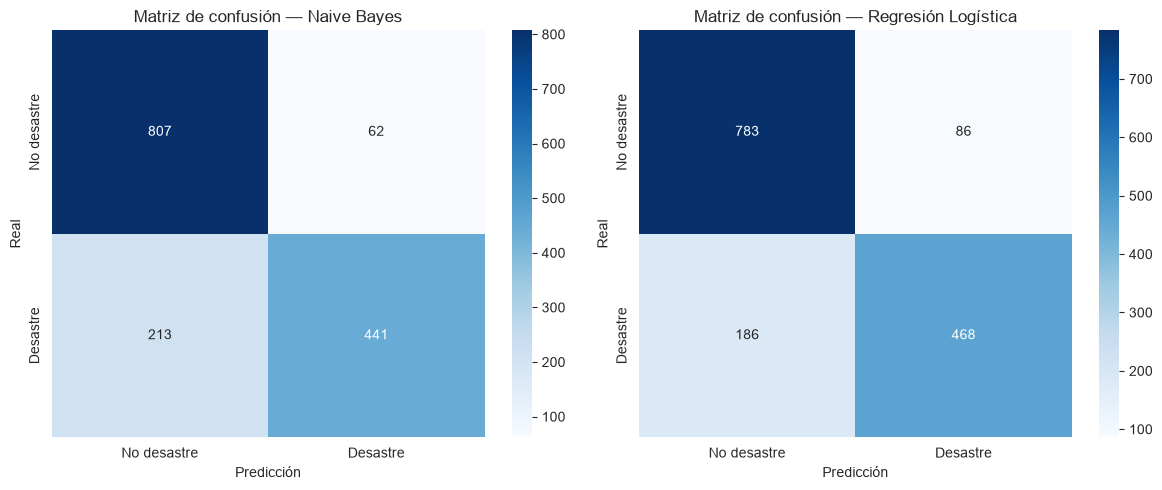

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nombre, y_pred) in zip(axes, [("Naive Bayes", y_pred_nb), ("Regresión Logística", y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No desastre", "Desastre"], yticklabels=["No desastre", "Desastre"])
    ax.set_title(f"Matriz de confusión — {nombre}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [33]:
print("Reporte de clasificación — Regresión Logística:\n")
print(classification_report(y_test, y_pred_lr, target_names=["No desastre", "Desastre real"]))

Reporte de clasificación — Regresión Logística:

               precision    recall  f1-score   support

  No desastre       0.81      0.90      0.85       869
Desastre real       0.84      0.72      0.77       654

     accuracy                           0.82      1523
    macro avg       0.83      0.81      0.81      1523
 weighted avg       0.82      0.82      0.82      1523



In [34]:
nombres_features = np.array(vectorizador_tfidf.get_feature_names_out())
coeficientes = modelo_lr.coef_[0]
orden = np.argsort(coeficientes)

top_positivos = pd.DataFrame({
    "n-grama": nombres_features[orden[-15:][::-1]],
    "coeficiente": coeficientes[orden[-15:][::-1]],
})
top_negativos = pd.DataFrame({
    "n-grama": nombres_features[orden[:15]],
    "coeficiente": coeficientes[orden[:15]],
})

print("N-gramas que más empujan la predicción hacia 'DESASTRE REAL':")
display(top_positivos)

print("\nN-gramas que más empujan la predicción hacia 'NO DESASTRE':")
display(top_negativos)

N-gramas que más empujan la predicción hacia 'DESASTRE REAL':


,n-grama,coeficiente
0,hiroshima,3.434339
1,fire,2.795034
2,wildfire,2.733111
3,california,2.590249
4,storm,2.554234
5,flood,2.455091
6,earthquake,2.333342
7,killed,2.299118
8,train,2.201943
9,bombing,2.165597



N-gramas que más empujan la predicción hacia 'NO DESASTRE':


,n-grama,coeficiente
0,love,-2.045980
1,let,-1.757410
2,new,-1.714832
3,want,-1.634385
4,full,-1.561491
5,bag,-1.541553
6,ruin,-1.539098
7,blew,-1.459738
8,bloody,-1.451552
9,harm,-1.437816


**Discusión del modelo preliminar:**

- Ambos modelos (Naive Bayes y Regresión Logística) logran un desempeño notablemente por encima de una línea base ingenua (predecir siempre la clase mayoritaria, que rondaría el 57% de *accuracy*), lo que confirma que el texto limpio junto con TF-IDF de unigramas + bigramas contiene señal útil para la tarea.
- Los n-gramas con mayor coeficiente positivo (tabla anterior) coinciden en buena parte con los unigramas/bigramas identificados como más discriminativos en las secciones 3 y 4, lo cual es una señal de consistencia entre el análisis exploratorio y lo que el modelo "aprende".
- Este es un modelo **preliminar**: para el informe final se plantea (i) probar algoritmos adicionales (p. ej. SVM lineal, Random Forest, Gradient Boosting), (ii) ajustar hiperparámetros (regularización, `min_df`/`max_features`, `ngram_range`), (iii) incorporar `keyword` como *feature* categórica, (iv) construir la función que reciba un tweet sin preprocesar y lo clasifique, y (v) incorporar la variable de "negatividad" (sentimiento) descrita en los puntos 8-10 del enunciado, comparando si mejora el desempeño obtenido aquí.

## 6. Conclusiones parciales y próximos pasos

**Resumen de hallazgos del avance:**

- El dataset tiene un desbalance moderado (~57% no desastre / ~43% desastre real) y algo de ruido de etiquetado (tweets idénticos con etiquetas distintas).
- `keyword` es una variable con señal fuerte; `location` es demasiado ruidosa para usarse sin normalizar.
- Los tweets de desastre real son en promedio más largos y contienen más URLs; los que no lo son contienen más menciones.
- El análisis de unigramas y bigramas muestra vocabulario claramente diferenciado entre clases, además de un núcleo de palabras "neutrales" compartidas por ambas — los bigramas ayudan a desambiguar varios de esos casos.
- Un modelo preliminar (TF-IDF de unigramas + bigramas con Naive Bayes / Regresión Logística) ya logra una mejora clara sobre una línea base ingenua.

**Pendiente para el informe final** (puntos 6 a 11 del enunciado):

1. Probar y comparar más algoritmos de clasificación, seleccionar el mejor con base en métricas.
2. Elaborar la función que reciba un tweet **sin preprocesar** y devuelva la clasificación.
3. Clasificar palabras en positivas/negativas/neutras y construir una variable de "negatividad" por tweet (evaluando si conviene conservar los emojis para ese análisis).
4. Identificar los 10 tweets más negativos y los 10 más positivos, y analizar en qué categoría (`target`) caen.
5. Verificar si los tweets de desastre real son, en promedio, más negativos que los que no lo son.
6. Reentrenar el modelo de clasificación incluyendo la variable de "negatividad" y discutir si mejora el desempeño obtenido en este avance.